В цьому домашньому завданні ми побудуємо рішення задачі логістичної регресії і створимо ваш перший submission на змагання на Kaggle. Усі кроки були розглянуті в лекції та містяться в ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb`, але тепер ми їх адаптуємо до іншої задачі - все як в реальному житті, коли ви знайшли код у відкритих джерелах і адаптуєте на проєкті 😉

**Погнали! 🚀🚀🚀**

-----------



0. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle) Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").

1. Зчитайте дані `train.csv` в pandas dataframe та розбийте їх на train і validation піднабори.

  * Є такий параметр в методі train_test_split як stratified. Можливо він буде Вам корисним при розбитті даних в цій задачі. Пропоную Вам почитати про нього в документації і спробувати скористатись.

In [1]:
import joblib
import warnings
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, roc_curve, roc_auc_score, 
                             f1_score, ConfusionMatrixDisplay, RocCurveDisplay, accuracy_score)

In [2]:
train_df = pd.read_csv('train.csv')
train_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


2. Визначіть назви колонок, які сформують вхідні незалежні дані, в змінній `input_cols` та назву колонки , яка є цільовою, в змінній `target_col`. Використовуючи `input_cols` та `target_col` створіть набори даних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` - де `inputs` - вхідні дані (датафрейм), `targets` - дані цільової колонки відповідного піднабору.

In [3]:
target_col = ['Exited']
input_cols = list(set(train_df.columns).difference(target_col))

target = train_df[target_col]
inputs = train_df[input_cols]

train_inputs, val_inputs, train_targets, val_targets = train_test_split(inputs, target, test_size=0.25, random_state=42, stratify=target)

3. Визначіть з допомогою `pandas.DataFrame.select_dtypes` назви колонок, які є числовими і категоріальними. Запишіть результати в `numeric_cols` та `categorical_cols` відповідно.

In [4]:
categorical_cols = train_df.select_dtypes(include = "object").columns.to_list()
print("Categorical columns:\n", categorical_cols)

numeric_cols = train_df.select_dtypes(include = "number").columns.difference(target_col).to_list()
print("Numeric columns:\n", numeric_cols)

Categorical columns:
 ['Surname', 'Geography', 'Gender']
Numeric columns:
 ['Age', 'Balance', 'CreditScore', 'CustomerId', 'EstimatedSalary', 'HasCrCard', 'IsActiveMember', 'NumOfProducts', 'Tenure', 'id']


4. Зробіть підготовку даних в категоріальних і числових колонках для входу в модель виходячи з освоєного на даний момент на курсі. Варіанти пеердобробки, з якими ми вже знайомі:
  - масштабування числових ознак,
  - заповнення пропущених значень, якщо вони є,
  - кодування категоріальних ознак, вилучення ознак, якщо ми вважаємо, що ці дані нерелевантні для моделі аби ми не бачимо способу як їх так закодувати, аби подати на вхід моделі.

  Тут є багато варіантів, як Ви побудуєте передобробку, важливо аби
  1) передобробка мала сенс (немає сенсу заповнювати дані константою, яку ми не зрозуміло звідки взяли)   
  2) має бути виконана принаймні одна дія передобробки
  3) обробка маэ бути виконана коректно і для тренувальних, і для вал. даних
  4) чим вищий у Вас врешті вийде ROС AUC скор, тим більше шансів перемогти у змаганні :)

  Опишіть рішення проведення кожного з кроків передобробки. Для чого ви його робите? По завершенню виведіть по 5 значен з `train_inputs`, `val_inputs` використовуючи `display()`.

In [5]:
# перевірка на пропущені значення
print(train_df.isna().values.sum())

0


In [6]:
# кількість унікальних значень для категоріальних колонок
print(f"train_df nunique values: \n{train_df[categorical_cols].nunique()}")

train_df nunique values: 
Surname      764
Geography      3
Gender         2
dtype: int64


In [7]:
for col in ['Gender', 'Geography']:
    print(train_df[col].unique().tolist())

['Male', 'Female']
['France', 'Germany', 'Spain']


In [8]:
# кодування бінарної категоріальної колонки
gender_codes = {'Male': 0, 'Female': 1}
gender_col = 'GenderCode'
train_inputs[gender_col] = train_inputs.Gender.map(gender_codes)
val_inputs[gender_col] = val_inputs.Gender.map(gender_codes)

# кодування мультикатегоріальної колонки
cols_to_encode = ['Geography']
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit(train_inputs[cols_to_encode])
encoded_cols = list(encoder.get_feature_names_out(cols_to_encode))

train_inputs[encoded_cols] = encoder.transform(train_inputs[cols_to_encode])
val_inputs[encoded_cols] = encoder.transform(val_inputs[cols_to_encode])

pd.set_option('display.max_columns', 100)
display(train_inputs.head()), display(val_inputs.head())

# було прийнято рішення не кодувати surname
# по-перше, занадто багато унікальних значень (764)
# по-друге, дуже малоймовірно, що на модель прізвище буде впливати (це скоріше ідентифікатор, аніж фіча)

,Tenure,Balance,id,IsActiveMember,Geography,EstimatedSalary,CreditScore,CustomerId,Gender,HasCrCard,NumOfProducts,Age,Surname,GenderCode,Geography_France,Geography_Germany,Geography_Spain
8263,5.0,130627.66,8263,1.0,France,86786.41,696.0,15679299.0,Male,1.0,1.0,32.0,Toscani,0,1.0,0.0,0.0
14199,4.0,119825.75,14199,0.0,Germany,177737.04,632.0,15804862.0,Female,1.0,1.0,32.0,Kuo,1,0.0,1.0,0.0
1856,4.0,0.00,1856,1.0,France,162599.54,679.0,15613140.0,Female,1.0,2.0,22.0,Ejimofor,1,1.0,0.0,0.0
3013,3.0,0.00,3013,0.0,France,119814.25,705.0,15651955.0,Male,1.0,2.0,48.0,Onochie,0,1.0,0.0,0.0
8266,7.0,0.00,8266,0.0,France,100423.88,696.0,15768471.0,Female,1.0,2.0,35.0,Chukwuemeka,1,1.0,0.0,0.0


,Tenure,Balance,id,IsActiveMember,Geography,EstimatedSalary,CreditScore,CustomerId,Gender,HasCrCard,NumOfProducts,Age,Surname,GenderCode,Geography_France,Geography_Germany,Geography_Spain
1855,9.0,119688.81,1855,0.0,France,55815.62,543.0,15751177.0,Male,0.0,1.0,29.0,Bitter,0,1.0,0.0,0.0
1273,3.0,123863.64,1273,0.0,Germany,176868.89,598.0,15685536.0,Male,1.0,1.0,41.0,Ting,0,0.0,1.0,0.0
5414,7.0,0.00,5414,1.0,France,150242.44,621.0,15710456.0,Male,1.0,1.0,31.0,Maclean,0,1.0,0.0,0.0
10923,3.0,0.00,10923,0.0,France,102936.71,597.0,15610355.0,Male,1.0,4.0,56.0,Chiang,0,1.0,0.0,0.0
5835,5.0,0.00,5835,1.0,Spain,181794.86,749.0,15778947.0,Female,1.0,1.0,42.0,Oluchi,1,0.0,0.0,1.0


(None, None)

In [9]:
numeric_cols = list(set(numeric_cols).difference(['id']))
# планувала і CustomerId видалити, але в даній реалізації з цією колонкою результат "на міліметр" краще
# повернуся до неї можливо в наступних ДЗ

In [10]:
scaler = StandardScaler()

train_inputs[numeric_cols] = scaler.fit_transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])

train_inputs.describe().round(2)
val_inputs.describe().round(2)


,Tenure,Balance,id,IsActiveMember,EstimatedSalary,CreditScore,CustomerId,HasCrCard,NumOfProducts,Age,GenderCode,Geography_France,Geography_Germany,Geography_Spain
count,3750.00,3750.00,3750.00,3750.00,3750.00,3750.00,3750.00,3750.00,3750.00,3750.00,3750.00,3750.00,3750.00,3750.00
mean,0.00,-0.01,7580.08,-0.01,-0.01,-0.00,0.01,-0.03,0.01,0.03,0.45,0.61,0.17,0.22
std,0.99,0.99,4335.60,1.00,1.02,1.01,0.47,1.02,1.00,1.04,0.50,0.49,0.38,0.41
min,-1.81,-0.72,1.00,-0.98,-2.58,-3.12,-0.83,-1.95,-1.11,-2.30,0.00,0.00,0.00,0.00
25%,-0.73,-0.72,3803.25,-0.98,-0.77,-0.79,-0.38,0.51,-1.11,-0.70,0.00,0.00,0.00,0.00
50%,-0.01,-0.72,7652.00,-0.98,0.12,0.04,-0.00,0.51,0.77,-0.08,0.00,1.00,0.00,0.00
75%,0.71,1.09,11384.75,1.02,0.87,0.68,0.44,0.51,0.77,0.53,1.00,1.00,0.00,0.00
max,1.79,2.39,14995.00,1.02,1.80,2.65,0.82,0.51,4.53,4.46,1.00,1.00,1.00,1.00


5. Збережіть дані, що містяться в змінних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` на диск в форматі `parquet`. В кінці виведіть список файлів в папці, в яку Ви зберегли файли і перевірте, чи файли збереглись. Вивести список файлів можна з `os.listdir(your_dir)` або `!ls your_dir`

In [11]:
datasets = {
    'train_inputs': train_inputs,
    'train_targets': train_targets,
    'val_inputs': val_inputs,
    'val_targets': val_targets,
}

for name, data in datasets.items():
    pd.DataFrame(data).to_parquet(f'{name}.parquet')

In [12]:
!ls *.parquet

train_inputs.parquet  val_inputs.parquet
train_targets.parquet val_targets.parquet


6. З підготовлених вхіжних даних створіть `X_train`, `X_val` набори, які містять лише колонки, які підуть на вхід моделі. Навчіть модель бінарної класифікації з допомогою `LogisticRegression` в `scikit-learn`.

In [13]:
cols_for_analysis = numeric_cols + [gender_col] + encoded_cols

X_train = train_inputs[cols_for_analysis]
X_val = val_inputs[cols_for_analysis]

model = LogisticRegression(class_weight='balanced', solver='liblinear')
model.fit(X_train, train_targets.squeeze())

y_pred_train = model.predict(X_train)
y_pred_val = model.predict(X_val)

7. Виведіть Confusion matrix, ROC Curve, метрику AUROC та метрику F1 Score для порога класифікації 0.5 для побудованої моделі на тренувальних та валідаційних даних. Що можете сказати про якіст моделі? Вона хороша, погана, задовільна?

=== Train ===
AUROC:    0.8847
F1 Score: 0.6504


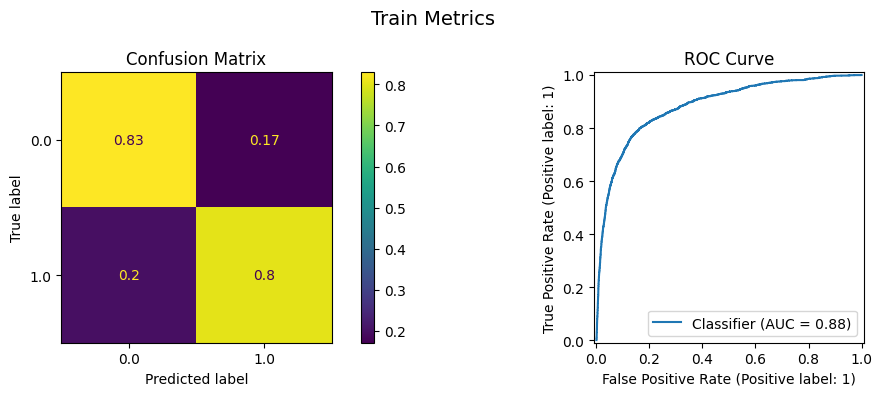

=== Validation ===
AUROC:    0.8803
F1 Score: 0.6381


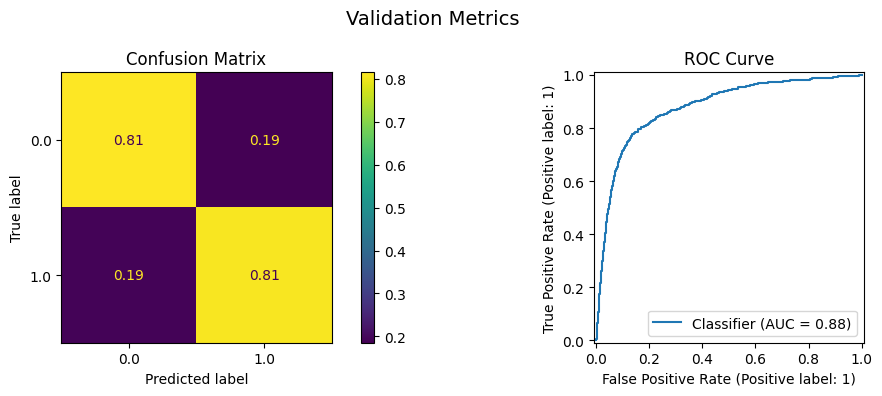

In [14]:
def evaluate_model(model, X, y, dataset_name='Train'):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]

    auroc = roc_auc_score(y, y_proba)
    f1 = f1_score(y, y_pred)
    
    print(f'=== {dataset_name} ===')
    print(f'AUROC:    {auroc:.4f}')
    print(f'F1 Score: {f1:.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'{dataset_name} Metrics', fontsize=14)

    ConfusionMatrixDisplay.from_predictions(y, y_pred, ax=axes[0], normalize='true')
    axes[0].set_title('Confusion Matrix')

    RocCurveDisplay.from_predictions(y, y_proba, ax=axes[1])
    axes[1].set_title('ROC Curve')
    
    plt.tight_layout()
    plt.show()

# Evaluate on both datasets
evaluate_model(model, X_train, train_targets, dataset_name='Train')
evaluate_model(model, X_val, val_targets, dataset_name='Validation')

8. Створіть передбачення моделі, яка передбачає завжди мажоритарний клас (той, якого більше в тренувальних даних). Порахуйте Accuracy на тренувальних та валідаційних даних для цієї моделі і тої, що ми натренували в п.6. Зробіть заключення про якість нашої моделі: якість хороша, погана, задовільна?

In [15]:
train_df[target_col].value_counts()

Exited
0.0       11948
1.0        3052
Name: count, dtype: int64

Accuracy моделі, яка передбачає завжди мажоритарний клас: train 0.80, validation 0.80
Accuracy моделі, що ми натренували в п.6: train 0.82, validation 0.81
=== Train ===
AUROC:    0.5000
F1 Score: 0.0000


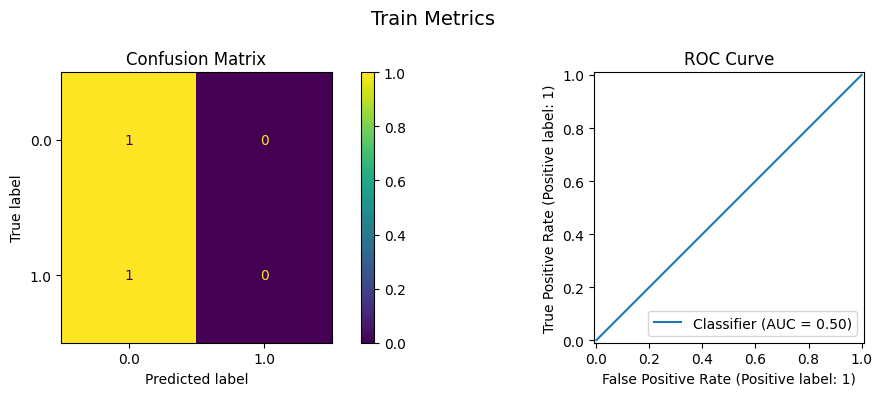

=== Validation ===
AUROC:    0.5000
F1 Score: 0.0000


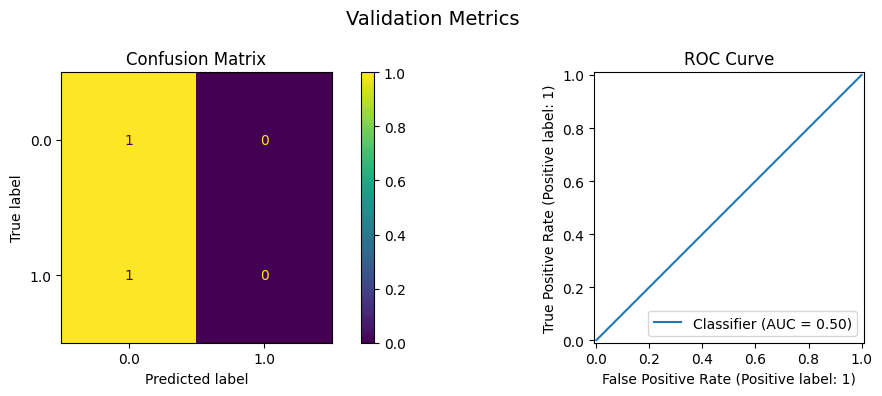

In [16]:
acc_train = accuracy_score(train_targets, model.predict(X_train))
acc_val = accuracy_score(val_targets, model.predict(X_val))

acc_train_major = accuracy_score(train_targets, np.zeros(len(train_targets)))
acc_val_major = accuracy_score(val_targets, np.zeros(len(val_targets)))
print(f"Accuracy моделі, яка передбачає завжди мажоритарний клас: train {acc_train_major:.2f}, validation {acc_val_major:.2f}")
print(f"Accuracy моделі, що ми натренували в п.6: train {acc_train:.2f}, validation {acc_val:.2f}")

def evaluate_zeros_model(X, y, dataset_name='Train'):
    y_pred = np.zeros(len(y))
    y_proba = y_pred

    auroc = roc_auc_score(y, y_proba)
    f1 = f1_score(y, y_pred)
    
    print(f'=== {dataset_name} ===')
    print(f'AUROC:    {auroc:.4f}')
    print(f'F1 Score: {f1:.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'{dataset_name} Metrics', fontsize=14)

    ConfusionMatrixDisplay.from_predictions(y, y_pred, ax=axes[0], normalize='true')
    axes[0].set_title('Confusion Matrix')

    RocCurveDisplay.from_predictions(y, y_proba, ax=axes[1])
    axes[1].set_title('ROC Curve')
    
    plt.tight_layout()
    plt.show()
evaluate_zeros_model(X_train, train_targets, dataset_name='Train')
evaluate_zeros_model(X_val, val_targets, dataset_name='Validation')

9. Збережіть модель і інші обʼєкти, які ви хотіли б зберегти, з використанням бібліотеки joblib в файл `log_reg.joblib`. Потім завантажте модель з файлу в змінну `model_2` (цим ми тренуємось завантажувати модель з файлу на майбутнє).

=== Train ===
AUROC:    0.8847
F1 Score: 0.6504


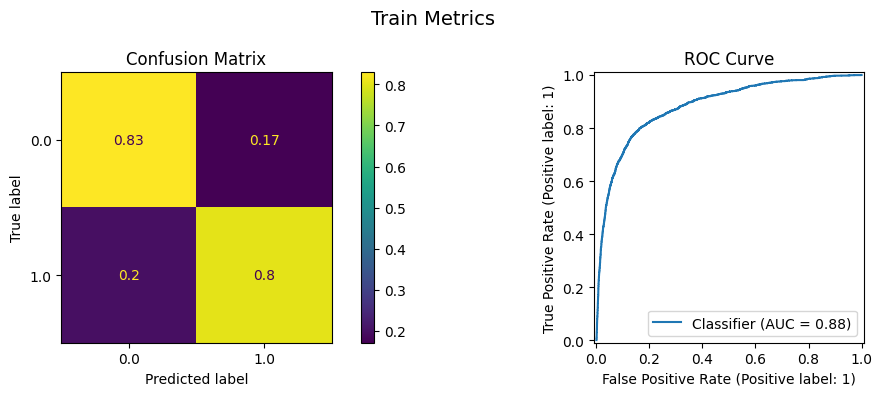

In [17]:
bank_customers = {
    'model': model,
    'scaler': scaler,
    'encoder': encoder,
    'input_cols': input_cols,
    'target_col': target_col,
    'numeric_cols': numeric_cols,
    'categorical_cols': categorical_cols,
    'encoded_cols': encoded_cols
}

joblib.dump(bank_customers, 'bank_customers.joblib')
model_2 = joblib.load('bank_customers.joblib')
model_2
# для перевірки
evaluate_model(model_2['model'], X_train, train_targets, dataset_name='Train')

10. Ознайомтесь з роботою наведеної функції `predict_raw_df`. Ця функція робить підготовку даних (масштабування числових колонок і кодування категоріальних) і виводить ймовірності належності до класу 1 для кожного рядка в наданому наборі.

Доповніть або внесіть зміни у функцію з врахуванням вашого препроцесингу даних.

In [18]:
warnings.filterwarnings("ignore")

def predict_raw_df(scaler, encoder, numeric_cols, categorical_cols, input_df: pd.DataFrame):
    gender_codes = {'Male': 0, 'Female': 1}
    gender_col = 'GenderCode'
    input_df[gender_col] = input_df.Gender.map(gender_codes)
    input_df[encoded_cols] = encoder.transform(input_df[categorical_cols])
    input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])
    X_input = input_df[numeric_cols + [gender_col] + encoded_cols]
    prob = model.predict_proba(X_input)[:,1]
    return prob
y_predict = predict_raw_df(scaler, encoder, numeric_cols, cols_to_encode, train_df[:5])

11. Зчитайте дані з `test.csv` в змінну `test_raw_df`. Зробіть передбачення для кожного рядка даних з функцією з попереднього завдання і запишіть результат в нову колонку `Exited` в датафреймі `test_raw_df`.

In [19]:
test_raw_df = pd.read_csv('test.csv')
test_raw_df['Exited'] = predict_raw_df(scaler, encoder, numeric_cols, cols_to_encode, test_raw_df)
test_raw_df

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,GenderCode,Geography_France,Geography_Germany,Geography_Spain,Exited
0,15000,-0.638939,Chu,-1.039842,Germany,Male,-0.944178,-1.086920,1.720620,-1.109137,0.512471,1.017939,0.877849,0,0.0,1.0,0.0,0.243943
1,15001,-0.320054,Mazzi,-1.497433,France,Male,0.161091,-0.008436,-0.716829,0.771748,0.512471,1.017939,-1.108070,0,1.0,0.0,0.0,0.141415
2,15002,0.167740,Onyekachi,0.651857,France,Male,0.652322,1.070048,-0.716829,0.771748,0.512471,-0.982377,0.853186,0,1.0,0.0,0.0,0.399359
3,15003,0.624532,Martin,0.804387,Spain,Male,0.897937,-0.727425,-0.716829,-1.109137,0.512471,1.017939,1.075825,0,0.0,0.0,1.0,0.448165
4,15004,-0.186364,Kenechukwu,-0.928911,Spain,Male,0.652322,1.070048,-0.716829,0.771748,0.512471,1.017939,0.565893,0,0.0,0.0,1.0,0.215973
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,24995,-0.318885,Chukwumaobim,-0.277191,Spain,Male,0.038283,1.789037,-0.716829,0.771748,0.512471,1.017939,-1.498700,0,0.0,0.0,1.0,0.091794
9996,24996,0.320374,Clements,0.263598,Spain,Male,0.161091,1.429542,-0.716829,0.771748,0.512471,1.017939,0.540242,0,0.0,0.0,1.0,0.095300
9997,24997,0.436388,Chidiebere,1.594771,France,Male,-0.944178,1.429542,-0.716829,0.771748,0.512471,-0.982377,-2.481685,0,1.0,0.0,0.0,0.051019
9998,24998,-0.072076,Yermakova,-0.887312,France,Male,0.038283,0.351058,1.700963,-1.109137,0.512471,-0.982377,0.188012,0,1.0,0.0,0.0,0.389378


12. Зчитайте файл 'sample_submission.csv' і зповніть колонку `Exited` передбаченими вашою моделлю значеннями для кожного відповідного `id` клієнта.
Виведіть перші 5 рядків фінального датасету, збережіть результат в файл `submission_log_reg.csv` (УВАГА! не запишіть випадково ще індекси рядків!) і здайте цей файл на Kaggle зі свого профіля натиснувши `Submit Prediction`.

In [20]:
sample_submission = pd.read_csv('sample_submission.csv')
sample_submission = sample_submission[['id']].merge(
    test_raw_df[['id', 'Exited']], 
    on='id', 
    how='left'
)
sample_submission.to_csv('submission_log_reg.csv', index=False)
sample_submission.head()

,id,Exited
0,15000,0.243943
1,15001,0.141415
2,15002,0.399359
3,15003,0.448165
4,15004,0.215973


Отриманий score на kaggle із цим розвязком - 0.88748